In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from gsm_benchmarker.results_analyser import ModelResultsAnalyser, MultiModelResultsAnalyser, MultiVariantMultiModelResultsAnalyser
from gsm_benchmarker.results_analyser.babblers import get_babbler_counts, plot_babblers_by_family, compare_babblers
from gsm_benchmarker.answer_extractor import AnswerExtractor, AnswerExtractionError


plt.style.use('seaborn-v0_8-muted')
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
pp = Path("../../../../data/gsm-symbolic/outputs").resolve()
p_standard = pp / "mini_20x50x4__14_11/final"
p_sep = pp / 'separated_targets_20x50x4__26_11/final'
p_code = pp / 'pilot_code_output_2x10x1__02_12/final'

In [3]:
results_standard = MultiModelResultsAnalyser(p_standard/'main_test', load_full_data=True)
results_sep = MultiModelResultsAnalyser(p_sep/'main_test', load_full_data=True)
results_code = MultiModelResultsAnalyser(p_code/'main_test', load_full_data=True)

Model: 100%|██████████| 20/20 [00:00<00:00, 66.32it/s]
/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/multi_model.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(full_data_dict.values(), keys=full_data_dict.keys(), names=['model', 'old_index'])
Model: 100%|██████████| 20/20 [00:00<00:00, 149.21it/s]
/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/multi_model.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat op

## Babblers vs new prompt format

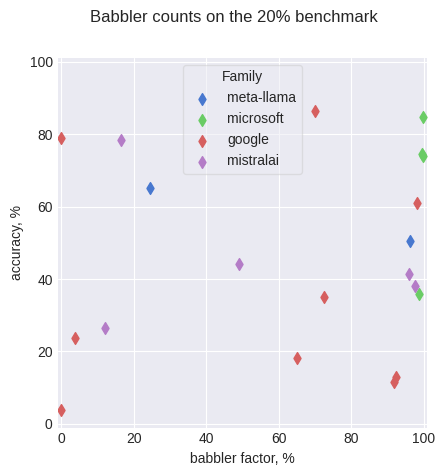

In [4]:
b_standard = get_babbler_counts(results_standard)
fig = plot_babblers_by_family(b_standard)
_ = fig.suptitle("Babbler counts on the 20% benchmark")

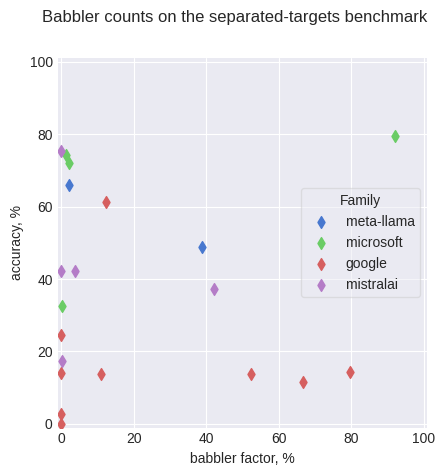

In [5]:
b_sep = get_babbler_counts(results_sep)
fig = plot_babblers_by_family(b_sep)
_ = fig.suptitle("Babbler counts on the separated-targets benchmark")

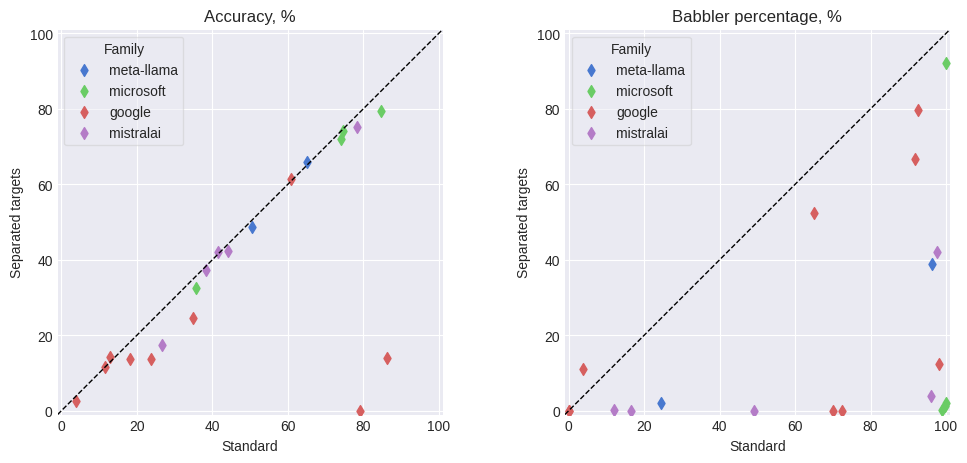

In [6]:
compare_babblers(b_standard, b_sep, "Standard", "Separated targets")


In [7]:
results_sep.full_data

,model,id,original_id,instance,question,answer,numerical_result,predicted_numerical_result,correct,detected_result_pattern,full_response,inference_time
0,meta-llama_Meta-Llama-3-8B,0,473,0,Rania saw a 210-foot whale with 7 72-inch remo...,"First, find the combined length of the remoras...",20.0,2.400,False,GSM_SYMBOLIC,A: Rania saw a 210-foot whale. 7 72-inch remor...,4.923265
1,meta-llama_Meta-Llama-3-8B,1,103,0,A fog bank rolls in from the ocean to cover a ...,The city will be covered in 77/ 77 = 1 interva...,50.0,50.000,True,GSM_SYMBOLIC,A: The city is 77 miles across. It takes 50 mi...,69.366779
2,meta-llama_Meta-Llama-3-8B,2,184,0,Luis is rolling a 4-sided die. How much more l...,There are 2 numbers greater than 2 on the dice...,25.0,NaN,False,None,A:,0.329735
3,meta-llama_Meta-Llama-3-8B,3,740,0,A group of 190 students has various hobbies. 1...,The number of students that like to hike is tw...,150.0,164.000,False,GSM_SYMBOLIC,A: There are 190 students. 19 like to paint. 7...,68.652929
4,meta-llama_Meta-Llama-3-8B,4,1264,0,Zahra is popping popcorn for a snack. As the p...,"In the second k_3 seconds of cooking, 4* 60 = ...",885.0,1910.750,False,GSM_SYMBOLIC,A: Zahra started with 60 pieces of popcorn. Af...,67.949864
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,mistralai_Mathstral-7B-v0_1,45,984,19,Daphne has a flower bed that is 175 meters lon...,Daphne's flower bed is 175 meters / 12.5 meter...,5.0,87.500,False,EQUAL_SIGN,\nA: Daphne's flower bed is 175 meters long. E...,10.045710
19996,mistralai_Mathstral-7B-v0_1,46,1031,19,Greenville High School is holding graduation i...,Add graduate and faculty seats together. 1250 ...,5.0,5.000,True,GSM_SYMBOLIC,A: There are 7900 seats in the Convention Cent...,6.758116
19997,mistralai_Mathstral-7B-v0_1,47,1164,19,Oliver hid 9 dozen eggs in the yard for the Ea...,Oliver hides 9 x 12 = 108 eggs.\nDaphne finds ...,18.0,20.000,False,GSM_SYMBOLIC,\nA: Oliver hid 9 dozen eggs. That is 9 x 12 =...,10.881453
19998,mistralai_Mathstral-7B-v0_1,48,989,19,Valeria can peel 7 carrots a minute and saute ...,First find how long it takes Valeria to peel t...,22.0,0.909,False,GSM_SYMBOLIC,A: Valeria can peel 7 carrots a minute. So in ...,8.253835


In [8]:
sep_prep = results_sep.full_data.set_index(['model', 'id', 'instance']).drop(['original_id', 'question', 'answer', 'numerical_result'], axis=1)
standard_prep = results_standard.full_data.set_index(['model', 'id', 'instance'])

standard_prep.columns = [('standard_' + c) if c in sep_prep.columns else c for c in standard_prep.columns]
sep_prep.columns = ['sep_' + c for c in sep_prep.columns]

combined = pd.concat([standard_prep, sep_prep], axis=1)
combined = combined.reset_index()
# combined

### Effect on accuracy

In [9]:
acc_down = combined[combined.standard_correct & ~combined.sep_correct]
acc_down

,model,id,instance,original_id,question,answer,numerical_result,standard_predicted_numerical_result,standard_correct,standard_detected_result_pattern,standard_full_response,standard_inference_time,sep_predicted_numerical_result,sep_correct,sep_detected_result_pattern,sep_full_response,sep_inference_time
6,meta-llama_Meta-Llama-3-8B,6,0,145,Pavel has 30 square yards of orange field. The...,Pavel has 94 x 30= 2820 oranges on his field.\...,2820.0,2820.0,True,GSM_SYMBOLIC,Pavel has 30 square yards of orange field. Th...,NaN,2800.00,False,GSM_SYMBOLIC,A: Pavel has 30 square yards of orange field. ...,59.271864
7,meta-llama_Meta-Llama-3-8B,7,0,459,A farmer is buying feed for his alpacas. He bu...,The farmer is buying 5 * 3 = 15 kgs of oats.\n...,9.0,9.0,True,GSM_SYMBOLIC,The farmer bought 5 x 3 = 15 kg of oats. He b...,NaN,1.00,False,GSM_SYMBOLIC,"A: The farmer bought 5 boxes of oats, each wei...",12.130359
11,meta-llama_Meta-Llama-3-8B,11,0,737,Pavel wants to make different sized ice cubes ...,The giant cubes used up 96 grams of water beca...,86.0,86.0,True,GSM_SYMBOLIC,Pavel has 328 grams of water. He makes 8 gian...,NaN,0.00,False,GSM_SYMBOLIC,A: Pavel started with 328 grams of water. He m...,6.657840
12,meta-llama_Meta-Llama-3-8B,12,0,491,Ravi places crackers on some trays. Each tray ...,Ravi will be able to place a total of 28 x 7 =...,56.0,56.0,True,GSM_SYMBOLIC,Ravi has 252 crackers. He has 7 trays. Each t...,NaN,2.00,False,GSM_SYMBOLIC,A: Ravi has 252 crackers. Each tray can hold 2...,4.184330
19,meta-llama_Meta-Llama-3-8B,19,0,1021,"In a 150-item quiz, 60% of the questions are h...",The literature and chemistry questions compris...,42.0,42.0,True,GSM_SYMBOLIC,There are 150 questions. 60% of 150 is 90. So...,NaN,150.00,False,EQUAL_SIGN,A: There are 150 questions. 60% of the questio...,68.761702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19905,mistralai_Mathstral-7B-v0_1,5,18,116,Ananya makes tea using teaspoons of sugar and ...,The total ratio representing the ingredients s...,788.0,788.0,True,GSM_SYMBOLIC,The ratio of sugar to water is 197:28. This m...,NaN,6615.00,False,GSM_SYMBOLIC,\nA: The ratio of sugar to water is 197:28. Th...,11.170576
19906,mistralai_Mathstral-7B-v0_1,6,18,145,Ali has 35 square meters of watermelon field. ...,Ali has 55 x 35= 1925 watermelons on his field...,11550.0,11550.0,True,GSM_SYMBOLIC,Ali has 35 square meters of watermelon field....,NaN,962.00,False,GSM_SYMBOLIC,A: Ali has 35 square meters of watermelon fiel...,8.141350
19951,mistralai_Mathstral-7B-v0_1,1,19,103,A fog bank rolls in from the ocean to cover a ...,The city will be covered in 9/ 9 = 1 intervals...,160.0,160.0,True,GSM_SYMBOLIC,The city is 9 miles across. The fog bank cove...,NaN,159.99,False,GSM_SYMBOLIC,A: The fog bank covers 9 miles in 160 minutes....,6.437361
19974,mistralai_Mathstral-7B-v0_1,24,19,43,"According to its nutritional info, a bag of po...",If the total calorie target is 2100 and I have...,125.0,125.0,True,GSM_SYMBOLIC,A bag of popcorn has 150 calories per serving...,NaN,600.00,False,GSM_SYMBOLIC,"A: First, we need to find out how many calorie...",16.743980


In [10]:
acc_up = combined[~combined.standard_correct & combined.sep_correct]
acc_up

,model,id,instance,original_id,question,answer,numerical_result,standard_predicted_numerical_result,standard_correct,standard_detected_result_pattern,standard_full_response,standard_inference_time,sep_predicted_numerical_result,sep_correct,sep_detected_result_pattern,sep_full_response,sep_inference_time
9,meta-llama_Meta-Llama-3-8B,9,0,930,"When Mei watches her brother, she gets out a v...",Let T be the number of bouncy balls in the tub...,59.0,349.0,False,GSM_SYMBOLIC,"Mei has 71 building blocks, 45 stuffed animal...",NaN,59.0,True,GSM_SYMBOLIC,"A: Mei started with 71 blocks, 45 stuffed anim...",4.690376
28,meta-llama_Meta-Llama-3-8B,28,0,955,A clinic has a capacity of 1800 rooms with 1/4...,If 1/4 of the total capacity of the clinic roo...,510.0,330.0,False,GSM_SYMBOLIC,The clinic has 1800 rooms. 1/4 of the rooms a...,NaN,510.0,True,GSM_SYMBOLIC,A: The clinic has 1800 rooms. 1/4 of the rooms...,69.176623
30,meta-llama_Meta-Llama-3-8B,30,0,873,Yusuf has ₣102.5 and wants to buy 25 washers f...,Yusuf paid 25 * ₣0.98 = ₣24.5 for the washers....,78.0,24.5,False,EQUAL_SIGN,Yusuf has ₣102.5. 25 washers at ₣0.98 each wi...,NaN,78.0,True,GSM_SYMBOLIC,A: Yusuf had 102.5 francs. 25 washers for 0.98...,59.839849
47,meta-llama_Meta-Llama-3-8B,47,0,1164,Umar hid 6 dozen eggs in the yard for the East...,Umar hides 6 x 12 = 72 eggs.\nQuinn finds 12 e...,11.0,3.0,False,GSM_SYMBOLIC,Umar hid 6 dozen eggs. Quinn found 12 eggs. I...,NaN,11.0,True,GSM_SYMBOLIC,A: Umar hid 6 dozen eggs. 6 dozen is 6 x 12 = ...,9.639141
50,meta-llama_Meta-Llama-3-8B,0,1,473,Olivia saw a 10-foot dolphin with 8 3-inch rem...,"First, find the combined length of the remoras...",20.0,2.4,False,GSM_SYMBOLIC,The dolphin is 10 feet long. Each remora is 3...,NaN,20.0,True,GSM_SYMBOLIC,A: The dolphin is 10 feet long. Each remora is...,7.378454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19948,mistralai_Mathstral-7B-v0_1,48,18,989,Haruka can peel 6 carrots a minute and saute 2...,First find how long it takes Haruka to peel th...,61.0,51.0,False,GSM_SYMBOLIC,Haruka can peel 6 carrots a minute. So to pee...,NaN,61.0,True,GSM_SYMBOLIC,A: Haruka can peel 6 carrots a minute. So to p...,8.082822
19952,mistralai_Mathstral-7B-v0_1,2,19,184,James is rolling a d20 die. How much more like...,There are 18 numbers greater than 2 on the dic...,65.0,3.6,False,GSM_SYMBOLIC,"A d20 die has 20 sides, numbered 1 to 20. The...",NaN,65.0,True,GSM_SYMBOLIC,\nA: The probability of rolling a number great...,6.393847
19954,mistralai_Mathstral-7B-v0_1,4,19,1264,Keisha is popping popcorn for a snack. As the ...,"In the second k_3 seconds of cooking, 3* 20 = ...",210.0,207.0,False,GSM_SYMBOLIC,"In the first 12 seconds, 20 kernels pop. In t...",NaN,210.0,True,GSM_SYMBOLIC,"\nA: In the first 12 seconds, 20 kernels pop. ...",13.731054
19956,mistralai_Mathstral-7B-v0_1,6,19,145,Mohammed has 55 square meters of orange field....,Mohammed has 54 x 55= 2970 oranges on his fiel...,11880.0,990.0,False,GSM_SYMBOLIC,Mohammed has 55 square meters of orange field...,NaN,11880.0,True,GSM_SYMBOLIC,A: Mohammed has 55 square meters of orange fie...,6.850590


In [11]:
def print_ex(qq):
    print("QUESTION")
    print(qq["question"])
    print(f"\nEXPECTED RESULT: {qq['numerical_result']}")
    print("\nSTANDARD PROMPT")
    print(AnswerExtractor.trim_response(qq["standard_full_response"]))
    print("\nSEPARATED TARGET")
    print(AnswerExtractor.trim_response(qq["sep_full_response"]))

In [12]:
print_ex(acc_down.iloc[0])

QUESTION
Pavel has 30 square yards of orange field. There are 94 oranges per square yard. Pavel can harvest his oranges every 12 months. How many oranges can Pavel harvest within a year?

EXPECTED RESULT: 2820.0

STANDARD PROMPT
 Pavel has 30 square yards of orange field. There are 94 oranges per square yard. So he has 30 x 94 = 2820 oranges. He can harvest his oranges every 12 months. So he can harvest 2820 oranges in 12 months. The final answer is 2820.



SEPARATED TARGET
A: Pavel has 30 square yards of orange field. There are 94 oranges per square yard. So he has 30 x 94 = 2800 oranges. He can harvest his oranges every 12 months. So he can harvest 2800 oranges in 12 months. The final answer is: 2800.




In [13]:
print_ex(acc_down.iloc[8])

QUESTION
Hiroshi goes to the store to buy some tea. The normal brand of tea he buys costs ₺20 per kilogram. He had to buy a more expensive brand that costs 45% more since his favorite brand was sold out. He decides to buy a week's worth of tea and he uses 1 kilogram of tea per day. He also decided to buy himself a bagel for ₺3. How much did everything cost?

EXPECTED RESULT: 206.0

STANDARD PROMPT
 The normal brand of tea he buys costs ₺20 per kilogram. He had to buy a more expensive brand that costs 45% more. So the more expensive brand costs 20 + 20 * 0.45 = 29. The more expensive brand costs 9 more than the normal brand. Hiroshi uses 1 kilogram of tea per day. So he needs 7 days worth of tea. 7 x 1 = 7. So he needs 7 kilograms of tea. 7 x 29 = 203. So the tea costs 203. He also decided to buy himself a bagel for ₺3. So the total cost is 203 + 3 = 206. The final answer is 206.



SEPARATED TARGET
A: Hiroshi had to buy a more expensive brand of tea. The normal brand of tea he buys cos

In [14]:
print_ex(acc_up.iloc[0])

QUESTION
When Mei watches her brother, she gets out a variety of toys for him. The bag of building blocks has 71 blocks in it. The bin of stuffed animals has 45 stuffed animals inside. The tower of stacking rings has 29 multicolored rings on it. Mei recently bought a tube of bouncy balls, bringing her total number of toys for her brother up to 204. How many bouncy balls came in the tube?

EXPECTED RESULT: 59.0

STANDARD PROMPT
 Mei has 71 building blocks, 45 stuffed animals, 29 stacking rings, and 204 bouncy balls. So she has 71 + 45 + 29 + 204 = 349 toys. The final answer is 349 - 204 = 145.



SEPARATED TARGET
A: Mei started with 71 blocks, 45 stuffed animals, and 29 rings. So she had 71 + 45 + 29 = 145 toys. She bought 204 - 145 = 59 more toys. So she bought 59 bouncy balls. The final answer is: 59.


---

# Code output prompt

In [15]:
results_code.summary_data

,accuracy,std
meta-llama_Meta-Llama-3-8B,0.25,0.070711
microsoft_Phi-3-medium-128k-instruct,0.95,0.070711
google_gemma-7b,0.20,0.141421
google_gemma-2-9b-it,0.90,0.000000
google_gemma-2-9b,0.00,0.000000
microsoft_phi-2,0.65,0.070711
meta-llama_Meta-Llama-3-8B-Instruct,0.60,0.000000
mistralai_Mistral-7B-v0_1,0.25,0.212132
google_gemma-7b-it,0.30,0.000000
google_gemma-2b-it,0.05,0.070711


In [16]:
comp = pd.concat([results_standard.summary_data.accuracy, results_sep.summary_data.accuracy, results_code.summary_data.accuracy], axis=1) * 100
comp.columns = ['accuracy - standard', 'accuracy - separated_targets', 'accuracy - code']
comp

,accuracy - standard,accuracy - separated_targets,accuracy - code
meta-llama_Meta-Llama-3-8B,50.6,48.7,25.0
microsoft_Phi-3-medium-128k-instruct,84.7,79.4,95.0
google_gemma-7b,18.2,13.7,20.0
google_gemma-2-9b-it,79.0,0.0,90.0
google_gemma-2-9b,60.9,61.3,0.0
microsoft_phi-2,35.8,32.6,65.0
meta-llama_Meta-Llama-3-8B-Instruct,65.0,65.9,60.0
mistralai_Mistral-7B-v0_1,38.2,37.3,25.0
google_gemma-7b-it,23.7,13.7,30.0
google_gemma-2b-it,3.9,2.7,5.0


In [17]:
failed = results_code.full_data[results_code.full_data.predicted_numerical_result.isna()]

In [18]:
reasons = []
keep = []
for idx in range(len(failed)):
    row = failed.iloc[idx]
    try:
        AnswerExtractor.extract_answer_code(row['full_response'])
    except AnswerExtractionError as exc:
        reasons.append(str(exc))
        keep.append(True)
    else:
        reasons.append("")
        keep.append(False)
failed["reason"] = reasons
failed = failed[keep]
failed

/tmp/ipykernel_3609926/3212125779.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failed["reason"] = reasons


,model,id,original_id,instance,question,answer,numerical_result,predicted_numerical_result,correct,detected_result_pattern,full_response,inference_time,reason
3,meta-llama_Meta-Llama-3-8B,3,740,0,A group of 190 students has various hobbies. 1...,The number of students that like to hike is tw...,150.0,NaN,False,None,def solution():\n # given:\n students_to...,70.265516,Extracted function definition has invalid syntax
41,google_gemma-7b,1,103,0,A fog bank rolls in from the ocean to cover a ...,The city will be covered in 77/ 77 = 1 interva...,50.0,NaN,False,None,def solution():\n,90.174412,Extracted function definition has invalid syntax
44,google_gemma-7b,4,1264,0,Zahra is popping popcorn for a snack. As the p...,"In the second k_3 seconds of cooking, 4* 60 = ...",885.0,NaN,False,None,def solution():\n # given:\n popping_rat...,86.720273,The result returned by the extracted function ...
46,google_gemma-7b,6,145,0,Pavel has 30 square yards of orange field. The...,Pavel has 94 x 30= 2820 oranges on his field.\...,2820.0,NaN,False,None,def solution():\n # given:\n field_size ...,79.688016,Failed to obtain numerical answer by running e...
47,google_gemma-7b,7,459,0,A farmer is buying feed for his alpacas. He bu...,The farmer is buying 5 * 3 = 15 kgs of oats.\n...,9.0,NaN,False,None,def solution():\n # given:\n apples = 42...,79.207090,Extracted function definition has invalid syntax
48,google_gemma-7b,8,269,0,A juggler can juggle 640 balls. An eighth of t...,tennis balls:640 * 1/8=80\nwhite tennis balls:...,8.0,NaN,False,None,def solution():\n # given:\n number_of_b...,75.023542,The result returned by the extracted function ...
50,google_gemma-7b,0,473,1,Olivia saw a 10-foot dolphin with 8 3-inch rem...,"First, find the combined length of the remoras...",20.0,NaN,False,None,def solution():\n # given:\n dolphin_len...,80.454016,The result returned by the extracted function ...
54,google_gemma-7b,4,1264,1,Isabella is popping popcorn for a snack. As th...,"In the second k_3 seconds of cooking, 3* 20 = ...",210.0,NaN,False,None,def solution():\n # given:\n seconds_pop...,83.619601,The result returned by the extracted function ...
55,google_gemma-7b,5,116,1,Uma makes tea using teaspoons of sugar and cup...,The total ratio representing the ingredients s...,492.0,NaN,False,None,def solution():\n # given:\n sugar_to_wa...,82.749606,Extracted function definition has invalid syntax
58,google_gemma-7b,8,269,1,A juggler can juggle 420 balls. Half of the ba...,tennis balls:420 * 1/2=210\nteal tennis balls:...,70.0,NaN,False,None,def solution():\n # given:\n total,85.730319,Failed to obtain numerical answer by running e...


In [19]:
perc_failed  = failed.model.value_counts() / results_code.full_data.model.value_counts() * 100
perc_failed.name = "% failed answers"
perc_failed

model
google_gemma-2-27b-it                   10.0
google_gemma-2-2b                       25.0
google_gemma-2-2b-it                    10.0
google_gemma-2-9b                       30.0
google_gemma-2-9b-it                    10.0
google_gemma-2b                         20.0
google_gemma-2b-it                      10.0
google_gemma-7b                         50.0
google_gemma-7b-it                      10.0
meta-llama_Meta-Llama-3-8B               5.0
meta-llama_Meta-Llama-3-8B-Instruct      5.0
microsoft_Phi-3-medium-128k-instruct     NaN
microsoft_Phi-3-mini-128k-instruct       NaN
microsoft_Phi-3_5-mini-instruct         20.0
microsoft_phi-2                         10.0
mistralai_Mathstral-7B-v0_1              NaN
mistralai_Mistral-7B-Instruct-v0_1      10.0
mistralai_Mistral-7B-Instruct-v0_3       5.0
mistralai_Mistral-7B-v0_1                NaN
mistralai_Mistral-7B-v0_3                5.0
Name: % failed answers, dtype: float64

In [20]:
failed.reason.value_counts()

reason
Extracted function definition has invalid syntax                                                                                                                                17
The result returned by the extracted function (None, type: NoneType) is not a number                                                                                            12
Failed to find valid function definition in text                                                                                                                                 3
Failed to obtain numerical answer by running extracted function: name 'total' is not defined                                                                                     2
Failed to obtain numerical answer by running extracted function: name 'wheat_bags' is not defined                                                                                1
Failed to obtain numerical answer by running extracted function: name 'total_popcorn_in_next_18_se

In [22]:
def print_qq(qq):
    print(f"MODEL: {qq['model']}")
    print("\nQUESTION")
    print(qq["question"])
    print(f"\nEXPECTED RESULT: {qq['numerical_result']}")
    print("\nANSWER")
    print(10*'-')
    t = AnswerExtractor.trim_response(qq["full_response"])
    print(t)
    if len(t) != len(qq['full_response']):
        print("...")
    print(10*'-')

    try:
        print(AnswerExtractor.extract_answer_code(qq['full_response']))
    except AnswerExtractionError as exc:
        print("\nISSUE")
        print(exc)

In [23]:
print_qq(failed.iloc[0])

MODEL: meta-llama_Meta-Llama-3-8B

QUESTION
A group of 190 students has various hobbies. 19 like to paint, 7 like to play football, and the rest like to either bake or hike. How many like to bake if the number that like to hike is twice the number that prefer playing football?

EXPECTED RESULT: 150.0

ANSWER
----------
def solution():
    # given:
    students_total = 190  # total number of students
    students_paint = 19  # number of students that like to paint
    students_football = 7  # number of students that like to play football
    students_bake =?  # number of students that like to bake
    students_hike =?  # number of students that like to hike

    # to find: number of students that like to bake

    # solution:
    # first, calculate the number of students that like to hike
    students_hike = students_football * 2
    # next, calculate the number of students that like to bake
    students_bake = students_total - students_paint - students_football - students_hike
    retu

In [24]:
print_qq(failed.iloc[1])

MODEL: google_gemma-7b

QUESTION
A fog bank rolls in from the ocean to cover a city. It takes 50 minutes to cover every 77 miles of the city. If the city is 77 miles across from the oceanfront to the opposite inland edge, how many minutes will it take for the fog bank to cover the whole city?

EXPECTED RESULT: 50.0

ANSWER
----------
def solution():

----------

ISSUE
Extracted function definition has invalid syntax


In [45]:
print_qq(failed.iloc[22])

MODEL: google_gemma-7b-it

QUESTION
Rania saw a 210-foot whale with 7 72-inch remoras attached to it. What percentage of the whale's body length is the combined length of the remoras?

EXPECTED RESULT: 20.0

ANSWER
----------
```python
# Given information
whale_length = 210  # Length of the whale in feet
remora_length = 7 * 72  # Combined length of the remoras in inches

# To find: percentage of the whale's body length that the remoras cover

# Solution:
remora_length_in_feet = remora_length * 0.0833  # Convert inches to feet
remora_length_percentage = (remora_length_in_feet / whale_length) * 100  # Calculate percentage of the whale's body length that the remoras cover

print(remora_length_percentage)  # Print the result
```

**Note:** The answer to this question is a floating-point number. You may need to use the `round()` function to round the final answer to the nearest whole number.
----------

ISSUE
Failed to find valid function definition in text


In [51]:
print_qq(failed.iloc[24])

MODEL: google_gemma-2b-it

QUESTION
Luis is rolling a 4-sided die. How much more likely is it (expressed as a percentage) that he rolls a number greater than 2 than that he rolls two odd numbers in a row?

EXPECTED RESULT: 25.0

ANSWER
----------
```python
def solution():
    # define the number of outcomes for each roll
    outcomes_4 = 4
    outcomes_odd = 3

    # calculate the number of ways to roll a number greater than 2
    num_greater_than_2 = outcomes_4 - outcomes_odd

    # calculate the number of ways to roll two odd numbers in a row
    num_odd_doubles = outcomes_odd * outcomes_odd

    # calculate the percentage of ways to roll a number greater than 2
    percentage_greater_than_2 = (num_greater_than_2 / outcomes_4) * 100

    # return the percentage as a string
    return f"{percentage_greater_than_2:.2f}%"


if __name__ == "__main__":
    solution()
```
----------

ISSUE
The result returned by the extracted function (25.00%, type: str) is not a number


In [70]:
print_qq(failed.iloc[41])

MODEL: microsoft_Phi-3_5-mini-instruct

QUESTION
Luis is rolling a 4-sided die. How much more likely is it (expressed as a percentage) that he rolls a number greater than 2 than that he rolls two odd numbers in a row?

EXPECTED RESULT: 25.0

ANSWER
----------

```python
import random

# Given:
# A 4-sided die has 4 outcomes: 1, 2, 3, 4
# Odd numbers on a 4-sided die are: 1, 3
# Probability of rolling a number greater than 2 (i.e., 3 or 4) is 2 out of 4
prob_greater_than_2 = 2 / 4

# Probability of rolling an odd number on a single roll is 2 out of 4
prob_odd_number = 2 / 4

# Probability of rolling two odd numbers in a row is the product of the probabilities
# of each individual event, since they are independent
prob_two_odd_numbers = prob_odd_number * prob_odd_number

# Calculate the difference in probabilities
diff_prob = prob_greater_than_2 - prob_two_odd_numbers

# Convert the difference to a percentage
diff_prob_percent = diff_prob * 100

# Output the result
print(f"The likelihood